In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression,SGDRegressor
from sklearn.metrics import r2_score 
from sklearn.preprocessing import StandardScaler,PolynomialFeatures 
from sklearn.pipeline import Pipeline

In [21]:
X=6*np.random.rand(200,1)-3
y=0.3*X**2 + 0.3*X +10+np.random.rand(200,1)

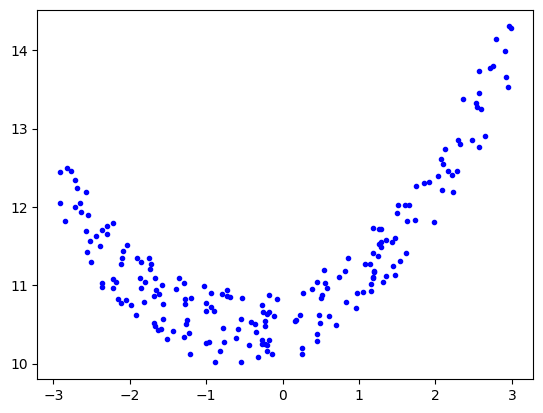

In [22]:
plt.plot(X,y,'b.')


In [31]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

In [32]:
lr=LinearRegression()

In [33]:
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [34]:
lr.predict(X_test)

array([[10.86031513],
       [11.09836383],
       [11.00317539],
       [11.3701289 ],
       [10.6766206 ],
       [11.36471946],
       [11.34677108],
       [11.7473242 ],
       [11.07943878],
       [11.1029193 ],
       [11.17156066],
       [11.22473057],
       [12.090923  ],
       [11.77285543],
       [11.73241265],
       [11.8370477 ],
       [11.23424622],
       [11.22595735],
       [11.27465545],
       [11.75465121],
       [11.71686769],
       [11.48255543],
       [11.37170416],
       [12.18367953],
       [11.39840177],
       [11.61132011],
       [11.21269981],
       [11.85035615],
       [10.97705161],
       [10.9737976 ],
       [11.54856037],
       [10.86625002],
       [11.26431717],
       [10.9398512 ],
       [11.01943894],
       [11.94961662],
       [11.34642751],
       [11.25801717],
       [11.98469286],
       [11.96382834]])

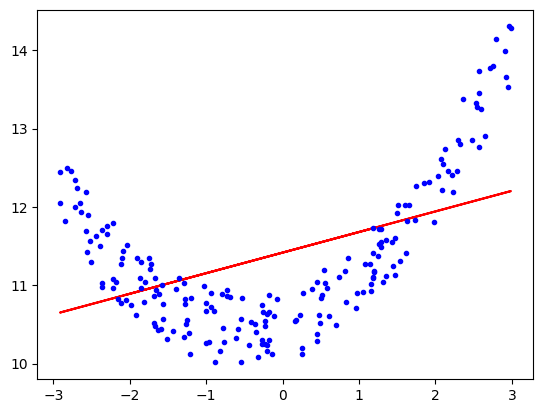

In [45]:
plt.plot(X_train,lr.predict(X_train),color='r') #straight line which is basically underfitting the data
plt.plot(X,y,'b.')

In [39]:
r2_score_linear=r2_score(y_test,lr.predict(X_test))
r2_score_linear #negative which means that the regrssion line is even worse than th emena line 

0.26647695338079525

In [84]:
poly=PolynomialFeatures(degree=2,include_bias=True)
X_train_trans=poly.fit_transform(X_train)
X_test_trans=poly.fit_transform(X_test)

In [85]:
print(X_train[0])
print(X_train_trans[0])

[1.18364256]
[1.         1.18364256 1.40100972]


In [86]:
#now applying linear regression on the transformed data 
lr=LinearRegression()

In [87]:
lr.fit(X_train_trans,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [88]:
predict=lr.predict(X_test_trans)

In [89]:
r2_score_poly=r2_score(y_test,predict)
r2_score_poly

0.8562161990167192